In [ ]:
import numpy as np

#? experience(years), problem_solving skills, pause_time, gpa
x = np.array([
    [1,4,1.5,3.8],
    [3,6,1.1,3.1],
    [4,7,0.8,3.9],
    [6,8,0.4,3.4],
    [7,9,0.2,2.8]
])

#? salary
# y = np.array([45,60,72,85,95])
y = np.array([45.9,76.35,92.35,112.9,128]) #? generated using pre-assumed 'w' and 'b'...see in the cost optimization part below

#* weights and bias assumed as --> w=[5,10,-2,0.5], b=2

Text(0, 0.5, 'Salary')

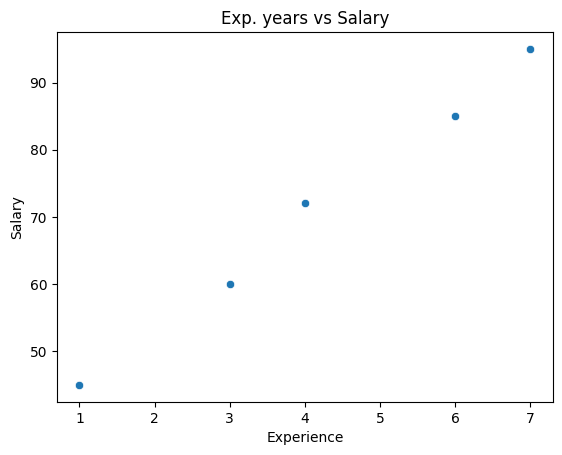

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(x=x[:,0],y=y)
plt.title("Exp. years vs Salary")
plt.xlabel("Experience")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

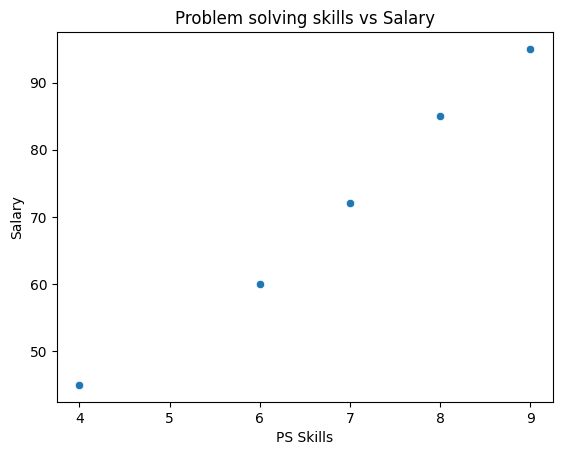

In [3]:
sns.scatterplot(x=x[:,1],y=y)
plt.title("Problem solving skills vs Salary")
plt.xlabel("PS Skills")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

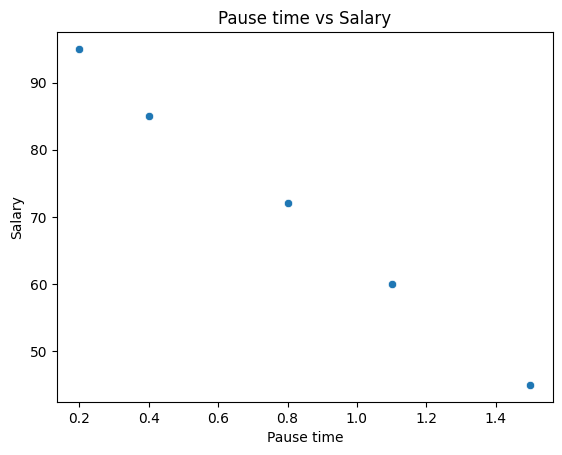

In [4]:
sns.scatterplot(x=x[:,2],y=y)
plt.title("Pause time vs Salary")
plt.xlabel("Pause time")
plt.ylabel("Salary")

Text(0, 0.5, 'Salary')

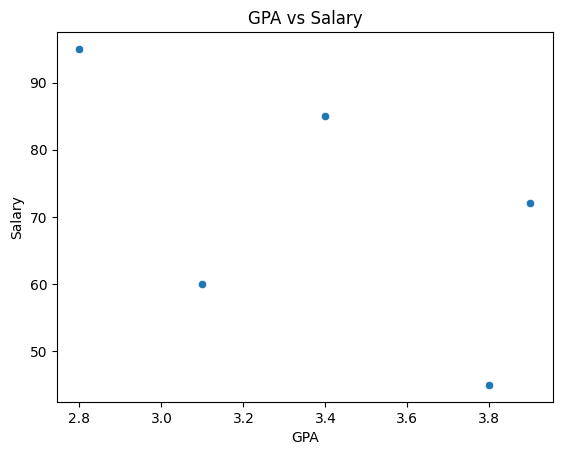

In [5]:
sns.scatterplot(x=x[:,3],y=y)
plt.title("GPA vs Salary")
plt.xlabel("GPA")
plt.ylabel("Salary")

In [12]:
def make_prediction(x,w,b):
    m = x.shape[0];
    prediction_list = np.zeros(m,)
    
    for i in range(m):
        prediction_list[i] = np.dot(w,x[i]) + b; 
        # x[i] is each row of the matrix 'x', so x[i] is an array, the dot product is happening between w(vector/array of weights) and x[i](vector/array of features). There will be a prediction for each row.
    
    return prediction_list;

In [ ]:
m = x.shape[0] #* rows
n = x.shape[1] #* columns

w_init = np.ones(n,);
b_init = 1;

print(make_prediction(x,w_init,b_init))

[11.3 14.2 16.7 18.8 20. ]


### Cost Function<br>
J(W,b) = 1/ (2*m) * (summation of (Ypi - Yai)^2 + ... + (Ypm - Yam)^2)..a = actual value, p = predicted value

In [ ]:
def compute_cost(x,y,w,b):
    m = x.shape[0];
    
    prediction_list = make_prediction(x,w,b);
    
    error = prediction_list - y; #? prediction array - actual values array
    error_squared = error ** 2; #? square of the error array
    cost = np.sum(error_squared);
    
    cost = cost/(2*m);
    
    return cost;

In [9]:
m = x.shape[0] #* rows
n = x.shape[1] #* columns

w_init = np.ones(n,);
b_init = 1.1;

print(compute_cost(x,y,w_init,b_init))

1624.3710000000003


### **Gradient Descent**

In [10]:
def calculate_gradient(x,y,w,b):
    nRows = x.shape[0]; #? number of rows
    nCols = x.shape[1]; #? number of columns
    
    dj_dw = np.zeros(nCols,); #? derivatives of the cost function with respect to w (weights)
    dj_db = 0.0; #? derivative of the cost function with respect to b (bias)
    
    for row in range(nRows):
        prediction = np.dot(w,x[row]) + b;  #? vector of all weights(w) (dot) vector of all features(x) + bias
        error = prediction - y[row]; #? this 'error' will go to all weights for the corresponding features of the same row, then for the 2nd row, then for the 3rd row and so on...,,,see the nested loop below
        dj_db = dj_db +  error; #* bias - its just one
        
        for col in range(nCols):
            dj_dw[col] = dj_dw[col] + (error * x[row,col]); 
            #? dj_dw[col] is the 'weight' of the corresponding feature
            #? x[row,col] is the feature we are finding 'gradient' for
    
    #* gradient descent
    dj_dw = dj_dw/m;
    dj_db = dj_db/m;
    
    return dj_dw, dj_db;

In [11]:
nRows = x.shape[0]; #? number of rows
nCols = x.shape[1]; #? number of columns

w_init = np.ones(nCols,);
b_init = 1.0;

print(calculate_gradient(x,y,w_init,b_init)) #? returns an array of all weights(dj_dw), each weight is for the corresponding feature. The number of weights is equal to the number of features
#? returns the dj_db as well, gradient_descent of bias

(array([-262.9  , -400.26 ,  -37.33 , -184.158]), np.float64(-55.2))


### **Cost Optimization**

Generating the actual values list using pre-assumed 'w' and 'b', to verify the final 'w' and 'b' are correct

In [ ]:
# x = np.array([
#     [1,4,1.5,3.8],
#     [3,6,1.1,3.1],
#     [4,7,0.8,3.9],
#     [6,8,0.4,3.4],
#     [7,9,0.2,2.8]
# ])

# y = make_prediction(x,w=[5,10,-2,0.5],b=2) # this array will be used as the list of actual values,,so the predicted values and actual values will be similar and that will ensure the final 'w' and 'b' are correct

# print(y)
# # [45.9,76.35,92.35,112.9,128] this array will be used as 'y' --actual values